# Introduction

A Mach-Zehnder modulator is an optical device used to control the intensity of a light beam. It works by splitting a laser beam into two paths and then recombining them. By changing the properties of one or both paths, we can control whether the waves interfere constructively (bright output) or destructively (dark output), effectively turning the light on and off at very high speeds. This makes them ideal for encoding data onto light signals for fiber-optic communication. The "PIN" part refers to the P-type, Intrinsic, N-type semiconductor structure that is used to control the light paths. By applying a voltage across this PIN junction, we can change the refractive index of the material, which in turn changes the speed of light in that path, thus controlling the interference.

The operation of the PIN diode generates heat, especially at high modulation speeds and power levels. This heat can significantly affect the performance of the modulator in several ways:
- Refractive Index Change: The refractive index of silicon is sensitive to temperature. The heat generated can change the refractive index of the waveguides, leading to a drift in the operating point of the modulator and affecting its performance.
- Carrier Mobility: The mobility of charge carriers (electrons and holes) in the semiconductor is also temperature-dependent. This affects the speed and efficiency of the modulator.
- Reliability: Excessive heat can lead to device degradation and failure over time.
By including the thermal aspect in our simulation, we can accurately predict the modulator's performance under realistic operating conditions, optimize its design for thermal stability, and ensure its long-term reliability. This multiphysics approach, combining both charge transport and heat transfer, provides a more complete and accurate picture of the device's behavior.

This notebook demonstrates how to use Tidy3D's advanced multiphysics capabilities to perform a comprehensive simulation of a PIN Mach-Zehnder modulator, including both charge and heat transport. This notebook will guide you through setting up the geometry, defining the materials and their physical models, running the simulation, and analyzing the results. This specific version of the notebook uses the effective Density of States (DOS) model with temperature dependence.

In [1]:
import tidy3d as td
import numpy as np
import matplotlib.pyplot as plt
# TODO remove
from tidy3d_backend.run_heat import run_heat_sim
import tidy3d_backend
import pandas as pd

import scipy as sp
import h5py
import subprocess

Here, we define the geometric parameters for the different components of the Mach-Zehnder modulator. This includes the pad, rib, silicon-on-insulator (SOI) box, cathode, and anode. The dimensions and centers of these components are defined in micrometers.

In [2]:
z_size = 4 # µm

# pad size
pad_center = (0, -0.045, 0)
x_pad_w = 5
y_pad_h = 0.09
pad_size = (x_pad_w, y_pad_h, z_size)

# rib size
rib_center = (0, 0.11, 0)
x_rib_w = 0.5
y_rib_h = 0.22
rib_size = (x_rib_w, y_rib_h, z_size)

# enclosing box + sox
offset_soxbox = 1.7
soxbox_center = (0, offset_soxbox, 0)
y_soxbox_h = 5
x_box_w = 5
soxbox_size = (x_box_w, y_soxbox_h, z_size)

# cathode
cathode_center = (-2.25, 1, 0)
y_cathode_h = 2
x_cathode_w = 0.5
cathode_size = (x_cathode_w, y_cathode_h, z_size)

# anode
anode_center = (2.25, 1, 0)
y_cathode_h = 2
x_anode_w = 0.5
anode_size = (x_anode_w, y_cathode_h, z_size)

# Doping and Materials
This section defines the doping profiles and the physical properties of the materials used in the simulation.

Doping Profiles
- `Constant Doping`: A constant acceptor doping concentration is defined for the p-type epitaxial (pepi) layer.
- `Gaussian Doping`: Gaussian doping profiles are used for the n+, p+, n-well, and p-well regions. These profiles are defined with specific centers, sizes, concentrations, reference concentrations, and junction widths. The source parameter in `GaussianDoping` specifies the direction from which the doping is introduced.

In [3]:
# pepi
conc_cst = 1e15
acceptor_cst_doping = td.ConstantDoping(center=(0, -1, 0), size=(5.4, 4, 4), concentration=conc_cst)

junction_width_01 = 1e-1
junction_width_02 = 2e-1

# nplus
conc_nplus = 2e18
refconc_nplus = 1e8
donor_nplus_center = (-1.5, 0, 0)
donor_nplus_size = (2., 2,  z_size)
donor_nplus_doping = td.GaussianDoping(center=donor_nplus_center, size=donor_nplus_size,
                                       concentration=conc_nplus, ref_con=refconc_nplus, width=junction_width_01, source="ymax")

# pplus
conc_pplus = 2e18
refconc_pplus = 1e8
acceptor_pplus_center = (1.5, 0, 0)
acceptor_pplus_size = (2., 2,  z_size)
acceptor_pplus_doping = td.GaussianDoping(center=acceptor_pplus_center, size=acceptor_pplus_size,
                                          concentration=conc_pplus, ref_con=refconc_pplus, width=junction_width_01, source="ymax")

# nwell
conc_nwell = 1e20
refconc_nplus = 1e8
donor_nwell_center = (-1.8, -0.49995, 0)
donor_nwell_size = (1.4, 1.0001,  z_size)
donor_nwell_doping = td.GaussianDoping(center=donor_nwell_center, size=donor_nwell_size,
                                       concentration=conc_nwell, ref_con=refconc_nplus, width=junction_width_02, source="ymax")

# pwell
conc_pwell = 1e20
refconc_pwell = 1e8
acceptor_pwell_center = (1.8, -0.5, 0)
acceptor_pwell_size = (1.4, 1.0001,  z_size)
acceptor_pwell_doping = td.GaussianDoping(center=acceptor_pwell_center, size=acceptor_pwell_size,
                                          concentration=conc_pwell, ref_con=refconc_pwell, width=junction_width_02, source="ymax")

## Mobility models Models
To accurately model the semiconductor behavior, we use several advanced physical models:

- **Caughey-Thomas Mobility**: This model is used to describe the carrier mobility as a function of doping concentration and temperature for both electrons (mobility_n) and holes (mobility_p).
- **Fossum Carrier Lifetime**: The FossumCarrierLifetime model is used to define the carrier lifetime for electrons (fossum_n) and holes (fossum_p) which is dependent on the doping concentration.
- **Slotboom Bandgap Narrowing**: This model accounts for the reduction in the bandgap energy at high doping concentrations.
- **Isotropic Effective Density of States (DOS)**: A novel feature, `IsotropicEffectiveDOS`, is used to model the effective density of states for the conduction band (`N_c`) and valence band (`N_v`) based on the effective mass of the carriers. This is an alternative to using a constant value.
- **Varshni Energy Bandgap**: The VarshniEnergyBandGap model is used to describe the temperature dependence of the bandgap energy (Eg).

### Media

We define `MultiPhysicsMedium` objects to combine both the electrical (charge) and thermal (heat) properties of the materials.

- **Si_doping**: A `MultiPhysicsMedium` representing the doped silicon, incorporating the charge properties defined in `si_charge` and the thermal properties (conductivity and capacity) of silicon.
- **SiO2**: Represents the **silicon dioxide** with its insulator and thermal properties.
- **Al**: Represents the **aluminum** contacts with their conductor and thermal properties.
- **air** and contact media: These are defined as `FluidMedium` for the thermal simulations.

In [4]:
mobility_n=td.CaugheyThomasMobility(
    mu_min=52.2,
    mu=1471.0,
    ref_N=9.68e16,
    exp_N=0.68,
    exp_1=-0.57,
    exp_2=-2.33,
    exp_3=2.4,
    exp_4=-0.146,
)
mobility_p=td.CaugheyThomasMobility(
    mu_min=44.9,
    mu=470.5,
    ref_N=2.23e17,
    exp_N=0.719,
    exp_1=-0.57,
    exp_2=-2.23,
    exp_3=2.4,
    exp_4=-0.146,
)

alpha = 1
beta = 0
gamma = 1
sigma = 1
tau_n = 1e-7
tau_p = 2e-7
fossum_n = td.FossumCarrierLifetime(N0=7.1e15, A=alpha, B=beta, C=gamma, tau_300=tau_n, alpha=sigma, alpha_T=0)
fossum_p = td.FossumCarrierLifetime(N0=7.1e15, A=alpha, B=beta, C=gamma, tau_300=tau_p, alpha=sigma, alpha_T=0)

ni = 1 #Useless in this formulation
narrowing = td.SlotboomBandGapNarrowing(c2=0.5, n2=1e17, v1=0.0045*2, min_N=ni)

# Temperature dependent Eff. DOS
N_c_isotropic = td.IsotropicEffectiveDOS(m_eff=0.8)
N_v_isotropic = td.IsotropicEffectiveDOS(m_eff=1.3)
Eg_Varshni = td.VarshniEnergyBandGap(eg_0=1.16, alpha=7.02e-4, beta=1108)

# Temperature independent
N_c_cst = td.ConstantEffectiveDOS(N=N_c_isotropic.calc_eff_dos(T=300))
N_v_cst = td.ConstantEffectiveDOS(N=N_v_isotropic.calc_eff_dos(T=300))
Eg_cst = td.ConstantEnergyBandGap(eg=1.12)

si_charge = td.SemiconductorMedium(
    permittivity=11.7,
    N_c=N_c_isotropic,
    N_v=N_v_isotropic,
    E_g = Eg_Varshni,
    N_d = [donor_nplus_doping, donor_nwell_doping],
    N_a = [acceptor_cst_doping, acceptor_pplus_doping, acceptor_pwell_doping],
    mobility_n=mobility_n,
    mobility_p=mobility_p,
    R=[
        td.ShockleyReedHallRecombination(tau_n=fossum_n, tau_p=fossum_p),
        td.RadiativeRecombination(r_const=1.6e-14),
        td.AugerRecombination(c_n=2.8e-31, c_p=9.9e-32),
    ],
    delta_E_g=narrowing
)

## -- MATERIALS
si_capacity = 711
sio2_capacity = 709
al_capacity = 902

si_conductivity = 148 * 1e-6 # W/(µm*K)
sio2_conductivity = 1.38 * 1e-6 # W/(µm*K)
al_conductivity = 236 * 1e-6 # W/(µm*K)

Si_doping = td.MultiPhysicsMedium(
    charge=si_charge,
    heat=td.SolidMedium(conductivity=si_conductivity, capacity=si_capacity),
    name="Si_doping",
)

# define semiconductor materials
SiO2 = td.MultiPhysicsMedium(
    charge=td.ChargeInsulatorMedium(permittivity=3.9),
    heat=td.SolidMedium(conductivity=sio2_conductivity * 1, capacity=sio2_capacity),
    name="SiO2",
)

# define semiconductor materials
Al = td.MultiPhysicsMedium(
    charge=td.ChargeConductorMedium(conductivity=3.5e7 * 1e-6),
    heat=td.SolidMedium(conductivity=al_conductivity, capacity=al_capacity),
    name="Al",
)

air = td.MultiPhysicsMedium(
    heat=td.FluidMedium(),
    name="air"
)

contact_medium_left = td.Medium(
    heat_spec=td.FluidMedium(),
    name="contact_medium_left"
)

contact_medium_right = td.Medium(
    heat_spec=td.FluidMedium(),
    name="contact_medium_right"
)

contact_medium_bottom = td.Medium(
    heat_spec=td.FluidMedium(),
    name="contact_medium_bottom"
)

contact_medium_top = td.Medium(
    heat_spec=td.FluidMedium(),
    name="contact_medium_top"
)

## Geometries and Scene
The geometries defined earlier are used to create Structure objects. Each structure is assigned a medium that defines its physical properties. The collection of all these structures is then used to create a Scene which represents the complete simulation domain. The scene is plotted to visualize the geometry and the doping profile. The first plot shows the different materials in the scene, and the second plot shows the doping concentration across the device.

In [5]:
## -- GEOMETRIES
pad_structure = td.Structure(
    geometry=td.Box(center=pad_center, size=pad_size),
    medium=Si_doping,
    name="pad",
)
rib_structure = td.Structure(
    geometry=td.Box(center=rib_center, size=rib_size),
    medium=Si_doping,
    name="rib",
)

soxbox_structure = td.Structure(
    geometry=td.Box(center=soxbox_center, size=soxbox_size),
    medium=SiO2,
    name="soxbox",
)

cathode_structure = td.Structure(
    geometry=td.Box(center=cathode_center, size=cathode_size),
    medium=Al,
    name="cathode",
)

anode_structure = td.Structure(
    geometry=td.Box(center=anode_center, size=anode_size),
    medium=Al,
    name="anode",
)

cb_thick = 0.5
contact_bottom = td.Structure(
    geometry=td.Box(center=(0, -y_soxbox_h/2 + offset_soxbox - cb_thick/2, 0), size=(x_pad_w, cb_thick, 4)),
    medium=contact_medium_bottom,
    name="contact_bottom",
)

def createStructure(pad, rib):
    structures = [
    contact_bottom,
    soxbox_structure,
    cathode_structure,
    anode_structure,
    pad,
    rib]
    return structures
    
structures = createStructure(pad_structure, rib_structure)

Create a temperature independent density of state model by using`updated_copy` on existing classes

In [6]:
# Temperature independent DOS
si_charge_cst = si_charge.updated_copy(N_c=N_c_cst, N_v=N_v_cst, E_g=Eg_cst)
Si_doping_cst = Si_doping.updated_copy(charge=si_charge_cst)
pad_structure_cst = pad_structure.updated_copy(medium=Si_doping_cst)
rib_structure_cst = rib_structure.updated_copy(medium=Si_doping_cst)
structures_cst = createStructure(pad_structure_cst, rib_structure_cst)

In [7]:
# create scene
scene = td.Scene(
    structures=structures,
    medium=air
)
# create scene
scene_cst = td.Scene(
    structures=structures_cst,
    medium=air
)

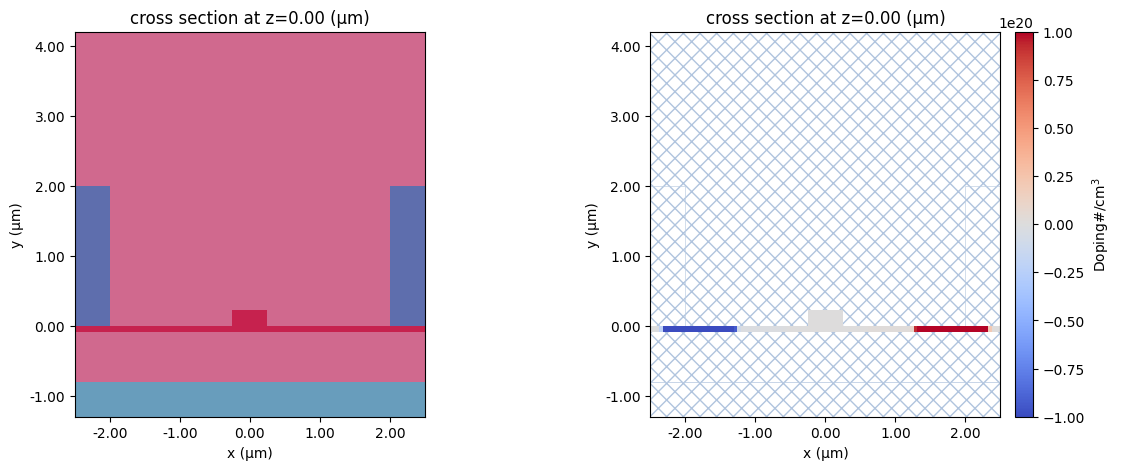

In [8]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

fig1 = scene.plot(z=0, ax=ax[0])
fig2 = scene.plot_structures_property(z=0, property="doping", ax=ax[1])
plt.show()

## Doping Profile Visualization
These plots provide a more detailed view of the doping concentration in the device. The four plots show the doping concentration with different color limits to highlight the p-type and n-type doping regions and their magnitudes.

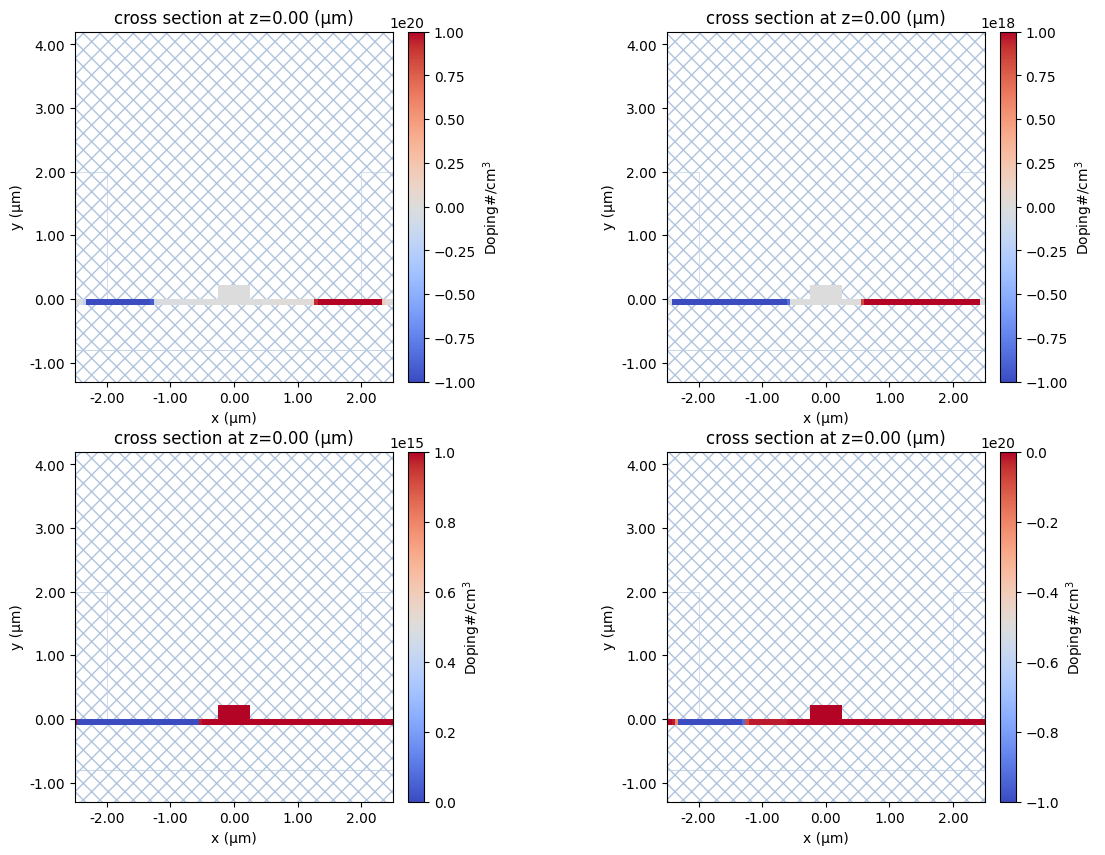

In [9]:
_, ax = plt.subplots(2,2, figsize=(14, 10))
fig1 = scene.plot_structures_property(z=0, property="doping", ax=ax[0][0],limits=[-1e20, 1e20])
fig2 = scene.plot_structures_property(z=0, property="doping", ax=ax[0][1],limits=[-1e18, 1e18])
fig3 = scene.plot_structures_property(z=0, property="doping", ax=ax[1][0],limits=[0, 1e15])
fig4 = scene.plot_structures_property(z=0, property="doping", ax=ax[1][1],limits=[-1e20, 0])

## Boundary Conditions
This section sets up the boundary conditions for the simulation.
- Charge Boundary Conditions: `HeatChargeBoundarySpec` is used to define the electrical boundary conditions. DC voltage sources are applied to the cathode and anode. The anode voltage is swept through a list of values from 0.5 to 1.2 Volt.
- Thermal Boundary Conditions: `HeatBoundarySpec` is used to define the thermal boundary conditions. Temperature boundary conditions are set at the interfaces between different structures. Temperature at electrodes is artifically increased up to 50 degress to showcase different simulation results between isothermal and non-isothermal analysis.

In [10]:
# cathode
voltages_cathode = [0]
bc_p = td.HeatChargeBoundarySpec(
    condition=td.VoltageBC(source=td.DCVoltageSource(voltage=voltages_cathode)),
    placement=td.StructureStructureInterface(structures=["cathode", "pad"])
)

voltages_anode = [0] +[0.5 + round((1/20)*x,5) for x in range(17)]
# anode
bc_n = td.HeatChargeBoundarySpec(
    condition=td.VoltageBC(source=td.DCVoltageSource(voltage=voltages_anode)),
    placement=td.StructureStructureInterface(structures=["anode", "pad"])
)
charge_bcs = [bc_n, bc_p]

# Ambient temperature for the heat sink model
temperature = 300
temperature_electrodes = 300
h = 200e-12

# cathode
bc3 = td.HeatBoundarySpec(
    # condition=td.TemperatureBC(temperature=temperature_electrodes),
    condition=td.ConvectionBC(ambient_temperature=temperature_electrodes, transfer_coeff=h),
    placement=td.StructureStructureInterface(structures=["cathode", "pad"]),
)
# anode
bc4 = td.HeatBoundarySpec(
    # condition=td.TemperatureBC(temperature=temperature_electrodes),
    condition=td.ConvectionBC(ambient_temperature=temperature_electrodes, transfer_coeff=h),
    placement=td.StructureStructureInterface(structures=["anode", "pad"]),
)

bc3a = td.HeatBoundarySpec(
    # condition=td.TemperatureBC(temperature=temperature_electrodes),
    condition=td.ConvectionBC(ambient_temperature=temperature_electrodes, transfer_coeff=h),
    placement=td.StructureStructureInterface(structures=["cathode", "soxbox"]),
)
# anode
bc4a = td.HeatBoundarySpec(
    # condition=td.TemperatureBC(temperature=temperature_electrodes),
    condition=td.ConvectionBC(ambient_temperature=temperature_electrodes, transfer_coeff=h),
    placement=td.StructureStructureInterface(structures=["anode", "soxbox"]),
)
# box
bc5 = td.HeatBoundarySpec(
    condition=td.TemperatureBC(temperature=temperature),
    placement=td.StructureStructureInterface(structures=["soxbox", "contact_bottom"])
)
thermal_bcs = [bc3, bc4, bc3a, bc4a, bc5]

## Monitors
Monitors are used to record the simulation results at different points in the simulation domain.

- `SteadyFreeCarrierMonitor`: Records the steady-state free carrier concentration.
- `SteadyPotentialMonitor`: Records the steady-state electric potential.
- `SteadyCapacitanceMonitor`: Records the capacitance of the device.
- `TemperatureMonitor`: Records the temperature distribution.

In [11]:
# monitors
charge_global_mnt = td.SteadyFreeCarrierMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, td.inf), name="charge_global_mnt", unstructured=True
)

potential_global_mnt = td.SteadyPotentialMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, td.inf), name="potential_global_mnt", unstructured=True
)

capacitance_global_mnt = td.SteadyCapacitanceMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, td.inf), name="capacitance_global_mnt", unstructured=True
)

temp_mnt = td.TemperatureMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, td.inf), name="temp_mnt", unstructured=True
)

monitors = [charge_global_mnt, potential_global_mnt, capacitance_global_mnt, temp_mnt]
monitors_iso = [charge_global_mnt, potential_global_mnt, capacitance_global_mnt]

## Simulation Setup
- Charge Tolerance: `ChargeToleranceSpec` sets the convergence criteria for the charge solver.
- Analysis Type: `SteadyChargeDCAnalysis` specifies a steady-state direct current (DC) analysis. The fermi_dirac=True argument indicates that Fermi-Dirac statistics should be used, which is more accurate for heavily doped semiconductors.
- Grid Specification: `DistanceUnstructuredGrid` is used to create a non-uniform mesh for the simulation. The mesh is refined in specific regions of interest using GridRefinementRegion to improve accuracy where needed, such as near the junctions.

In [12]:
charge_tolerance = td.ChargeToleranceSpec(rel_tol=1e-4, abs_tol=1e16, max_iters=400, ramp_up_iters=1)
analysis_type_iso = td.IsothermalSteadyChargeDCAnalysis(tolerance_settings=charge_tolerance,
                                                    convergence_dv=2,
                                                    fermi_dirac=False,
                                                    temperature=300)
analysis_type = td.SteadyChargeDCAnalysis(tolerance_settings=charge_tolerance,convergence_dv=2,fermi_dirac=False)

Here we can **manually** define the regions that require a finer mesh. This is particularly useful for resolving small features or areas where fields are expected to vary rapidly, without the computational cost of making the entire grid uniformly fine. In particular, an higher refinement is applied
- In the region where the doping concentration changes rapidly.
- In the proximity of corners (between the pad and the rib) to address singular fields.

Below it is shown an example on how the local refined mesh might look like. Automatic refinement will be featured in future versions of Tidy3D.

![Local_refinement](img/local_refinement.png "Local refinement visualization")

In [13]:
dl = 0.025
dl_ref = dl / 6
box_width = 0.12

# Interface between nwell and the rightmost side (not doped)
ref1 = td.GridRefinementRegion(
    center=(-2.35, -0.045, 0),
    size=(box_width, 0.1, 0),
    dl_internal=dl_ref,
    transition_thickness=dl * 20,
)

# Interface between pwell and the rightmost side (not doped)
ref2 = td.GridRefinementRegion(
    center=(2.35, -0.045, 0),
    size=(box_width, 0.1, 0),
    dl_internal=dl_ref,
    transition_thickness=dl * 20,
)

# refinement around the corner (left)
ref3 = td.GridRefinementRegion(
    center=(-0.25, -0.045, 0),
    size=(box_width, 0.1, 0),
    dl_internal=dl_ref,
    transition_thickness=dl * 20,
)

# refinement around the corner (right)
ref4 = td.GridRefinementRegion(
    center=(0.25, -0.045, 0),
    size=(box_width, 0.1, 0),
    dl_internal=dl_ref,
    transition_thickness=dl * 20,
)

# Interface between pepi and nplus
ref5 = td.GridRefinementRegion(
    center=(-1.25, -0.045, 0),
    size=(box_width, 0.1, 0),
    dl_internal=dl_ref,
    transition_thickness=dl * 20,
)

# Interface between pepi and pplus
ref6 = td.GridRefinementRegion(
    center=(1.25, -0.045, 0),
    size=(box_width, 0.1, 0),
    dl_internal=dl_ref,
    transition_thickness=dl * 20,
)

# Build a grid specification with all these custom refinements
grid_spec = td.DistanceUnstructuredGrid(
    relative_min_dl=0, 
    dl_interface=dl, 
    dl_bulk=20*dl, 
    distance_interface=2*dl, 
    distance_bulk=6*dl, 
    sampling=1000, 
    non_refined_structures=["soxbox"], 
    uniform_grid_mediums=["Si_doping"],
    mesh_refinements=[ref1, ref2, ref3, ref4, ref5, ref6]
)

In [14]:
sim_center = (0, offset_soxbox/2, 0)
sim_size = (4.8, 5, 0)

def createSim(structures, bcs, analysis_t):
    sim = td.HeatChargeSimulation(
        medium=air,
        structures=structures,
        size=sim_size,
        center=sim_center,
        boundary_spec=bcs,
        analysis_spec=analysis_t,
        monitors=monitors,
        grid_spec=grid_spec
    )
    return sim

sim = createSim(structures, charge_bcs + thermal_bcs, analysis_type)
sim_cst = createSim(structures_cst, charge_bcs + thermal_bcs, analysis_type)
sim_iso = createSim(structures_cst, charge_bcs, analysis_type_iso)

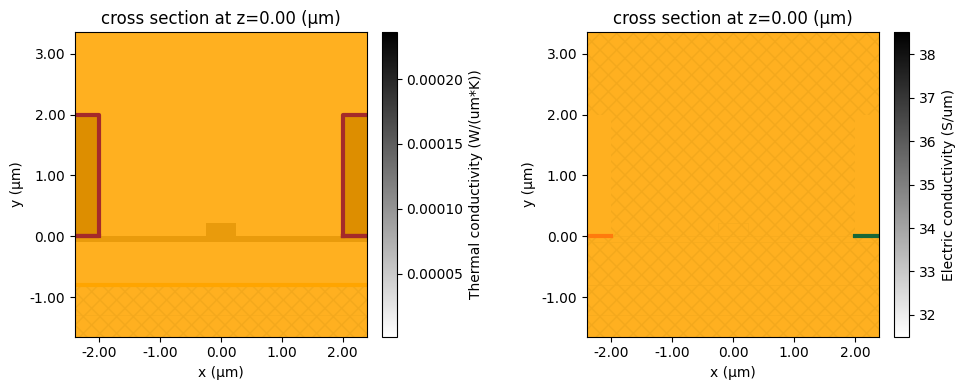

In [15]:
_, ax = plt.subplots(1, 2, figsize=(10, 4))
fig1 = sim.plot_property(z=0, property="heat_conductivity", ax=ax[0])
fig2 = sim.plot_property(z=0, property="electric_conductivity", ax=ax[1])
plt.tight_layout()

In [16]:
results_iso = run_heat_sim(sim=sim_iso, log_level="DEBUG")
subprocess.run(["cp", "-r", "tmp", "tmp_Ba_example_iso"]) 
subprocess.run(["cp", "output/simulation_data.hdf5", "tmp_Ba_example_iso/"]) 

[25-08-27 13:27:11.828][SUPPORT]: Setting up heat-charge simulation.                                
[25-08-27 13:27:11.848][SUPPORT]: Begin meshing heat-charge simulation.                             
[25-08-27 13:27:11.856][SUPPORT]: Begin adding structures to mesh.                                  
[25-08-27 13:27:11.862][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:11.869][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:11.875][SUPPORT]: Processing a Box.                                                 
[25-08-27 13:27:11.881][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:11.887][SUPPORT]: Processing a Box.                                                 
[25-08-27 13:27:11.892][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:11.898][SUPPORT]: Processing a Box.                                        

CompletedProcess(args=['cp', 'output/simulation_data.hdf5', 'tmp_Ba_example_iso/'], returncode=0)

In [17]:
results_cst =  run_heat_sim(sim=sim_cst, log_level="DEBUG")
subprocess.run(["cp", "-r", "tmp", "tmp_Ba_example_cst"]) 
subprocess.run(["cp", "output/simulation_data.hdf5", "tmp_Ba_example_cst/"]) 

[25-08-27 13:27:41.734][SUPPORT]: Setting up heat-charge simulation.                                
[25-08-27 13:27:41.751][SUPPORT]: Begin meshing heat-charge simulation.                             
Debug   : Destroying model model
Debug   : Destroying model 
[25-08-27 13:27:41.762][SUPPORT]: Begin adding structures to mesh.                                  
[25-08-27 13:27:41.768][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:41.775][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:41.781][SUPPORT]: Processing a Box.                                                 
[25-08-27 13:27:41.787][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:41.793][SUPPORT]: Processing a Box.                                                 
[25-08-27 13:27:41.799][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:27:41.805][SUPPOR

Debug   : BOOL (2,1) other                                                                                                             
Debug   : BOOL (3,1) replaced by 1
Debug   : BOOL (3,2) other
Debug   : BOOL (3,3) replaced by 1
Debug   : BOOL (3,4) replaced by 1
Debug   : BOOL (3,5) replaced by 1
Debug   : BOOL (3,6) other
Debug   : BOOL (2,38) other
Debug   : BOOL (2,39) other
Debug   : BOOL (2,40) other
Debug   : BOOL (2,41) other
Debug   : BOOL (2,42) other
Debug   : BOOL (2,43) other
Debug   : BOOL (2,44) other
Debug   : BOOL (2,45) other
Debug   : BOOL (2,46) other
Debug   : BOOL (2,47) other
Debug   : BOOL (2,48) other
Debug   : BOOL (2,49) other
Debug   : BOOL in (2,1) -> out (2,47) (2,48) (2,7) (2,13) (2,49) (2,8) (2,50) (2,51) (2,52) (2,53) (2,54) (2,12) (2,55) (2,56) (2,35) (2,36) (2,57) (2,58) (2,9) (2,59) (2,60) (2,11) (2,39) (2,61) (2,37) (2,62) (2,10) (2,63) (2,43) (2,42) (2,38) (2,44)
Debug   : BOOL in (3,1) -> out (3,1)
Debug   : BOOL in (3,2) -> out (3,6) (3,5) (3

CompletedProcess(args=['cp', 'output/simulation_data.hdf5', 'tmp_Ba_example_cst/'], returncode=0)

In [18]:
results = run_heat_sim(sim=sim, log_level="DEBUG")
subprocess.run(["cp", "-r", "tmp", "tmp_Ba_example"]) 
subprocess.run(["cp", "output/simulation_data.hdf5", "tmp_Ba_example/"]) 

[25-08-27 13:33:04.273][SUPPORT]: Setting up heat-charge simulation.                                
[25-08-27 13:33:04.291][SUPPORT]: Begin meshing heat-charge simulation.                             
Debug   : Destroying model model
Debug   : Destroying model 
[25-08-27 13:33:04.303][SUPPORT]: Begin adding structures to mesh.                                  
[25-08-27 13:33:04.310][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:33:04.316][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:33:04.323][SUPPORT]: Processing a Box.                                                 
[25-08-27 13:33:04.329][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:33:04.335][SUPPORT]: Processing a Box.                                                 
[25-08-27 13:33:04.342][SUPPORT]: Processing a single structure:                                    
[25-08-27 13:33:04.348][SUPPOR

Debug   : BOOL (2,1) other                                                                                                             
Debug   : BOOL (3,1) replaced by 1
Debug   : BOOL (3,2) other
Debug   : BOOL (3,3) replaced by 1
Debug   : BOOL (3,4) replaced by 1
Debug   : BOOL (3,5) replaced by 1
Debug   : BOOL (3,6) other
Debug   : BOOL (2,38) other
Debug   : BOOL (2,39) other
Debug   : BOOL (2,40) other
Debug   : BOOL (2,41) other
Debug   : BOOL (2,42) other
Debug   : BOOL (2,43) other
Debug   : BOOL (2,44) other
Debug   : BOOL (2,45) other
Debug   : BOOL (2,46) other
Debug   : BOOL (2,47) other
Debug   : BOOL (2,48) other
Debug   : BOOL (2,49) other
Debug   : BOOL in (2,1) -> out (2,47) (2,48) (2,7) (2,13) (2,49) (2,8) (2,50) (2,51) (2,52) (2,53) (2,54) (2,12) (2,55) (2,56) (2,35) (2,36) (2,57) (2,58) (2,9) (2,59) (2,60) (2,11) (2,39) (2,61) (2,37) (2,62) (2,10) (2,63) (2,43) (2,42) (2,38) (2,44)
Debug   : BOOL in (3,1) -> out (3,1)
Debug   : BOOL in (3,2) -> out (3,6) (3,5) (3

CompletedProcess(args=['cp', 'output/simulation_data.hdf5', 'tmp_Ba_example/'], returncode=0)

## Post-processing and Plotting
After the simulation is complete, this section processes the results and generates plots. The code reads the simulation data from the output files and plots:
- **Potential**: How the potential is distributed in the simulation region.
- **Temperature**: Same for temperature.
- **I-V Curve**: The current-voltage characteristic of the device.

### Potential distribution

In [19]:
pot_05V = results["potential_global_mnt"].potential.sel(voltage=0.5, z=0)
pot_12V = results["potential_global_mnt"].potential.sel(voltage=1.2, z=0)
pot_05V_cst = results_cst["potential_global_mnt"].potential.sel(voltage=0.5, z=0)
pot_12V_cst = results_cst["potential_global_mnt"].potential.sel(voltage=1.2, z=0)
pot_05V_iso = results_iso["potential_global_mnt"].potential.sel(voltage=0.5, z=0)
pot_12V_iso = results_iso["potential_global_mnt"].potential.sel(voltage=1.2, z=0)

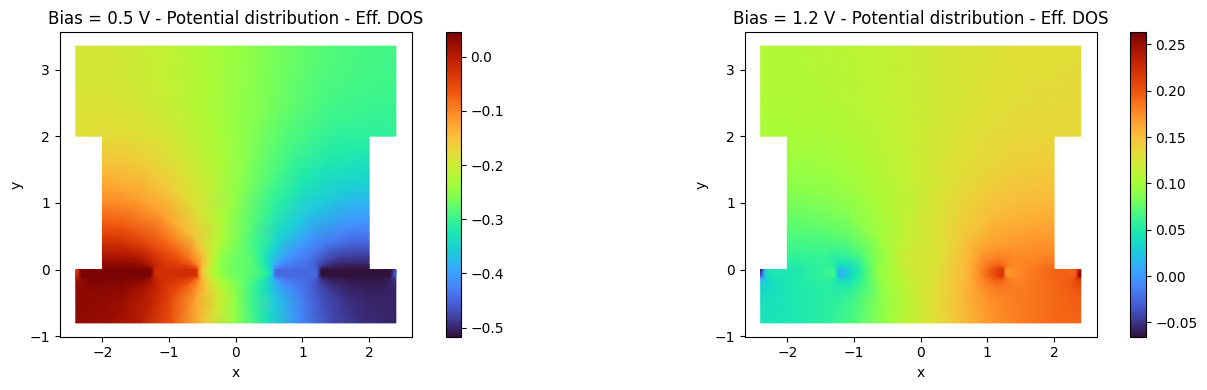

In [20]:
showGrid = False

fig, (ax) = plt.subplots(1, 2, figsize=(14, 4))

cont1 = pot_05V.plot(grid=showGrid, ax=ax[0], cmap="turbo")
cont2 = pot_12V.plot(grid=showGrid, ax=ax[1], cmap="turbo")

_ = ax[0].set_title(f"Bias = {0.5:.1f} V - Potential distribution - Eff. DOS")
_ = ax[1].set_title(f"Bias = {1.2:.1f} V - Potential distribution - Eff. DOS")

plt.tight_layout()

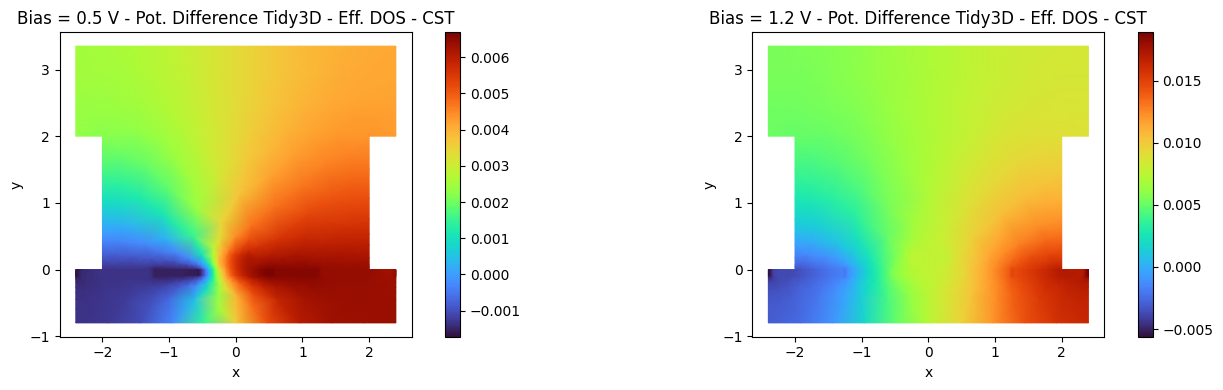

In [21]:
showGrid = False

fig, (ax) = plt.subplots(1, 2, figsize=(14, 4))

#pot = 0.0
p1 = (pot_05V - pot_05V_cst).plot(grid=showGrid, ax=ax[0], cmap="turbo")
p2 = (pot_12V - pot_12V_cst).plot(grid=showGrid, ax=ax[1], cmap="turbo")

_ = ax[0].set_title(f"Bias = {0.5:.1f} V - Pot. Difference Tidy3D - Eff. DOS - CST")
_ = ax[1].set_title(f"Bias = {1.2:.1f} V - Pot. Difference Tidy3D - Eff. DOS - CST")

plt.tight_layout()

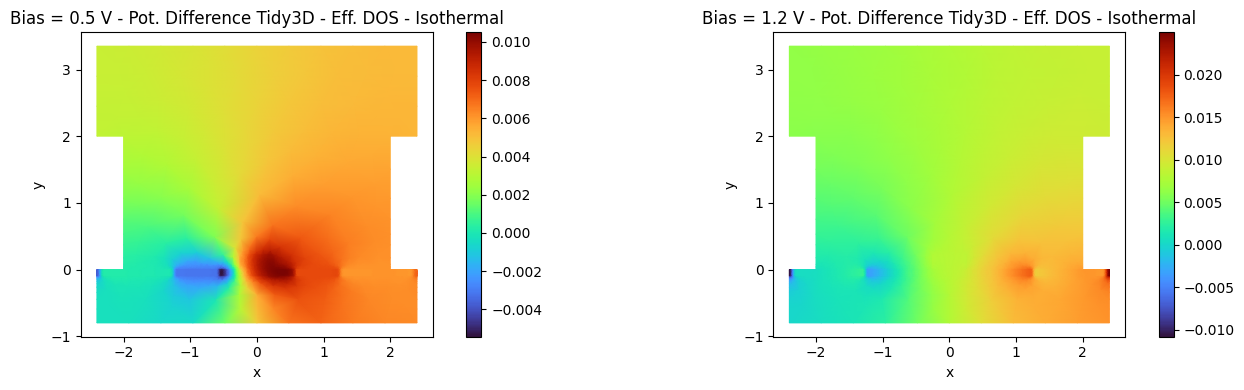

In [22]:
showGrid = False

fig, (ax) = plt.subplots(1, 2, figsize=(14, 4))

#pot = 0.0
p1 = (pot_05V - pot_05V_iso).plot(grid=showGrid, ax=ax[0], cmap="turbo")
p2 = (pot_12V - pot_12V_iso).plot(grid=showGrid, ax=ax[1], cmap="turbo")

_ = ax[0].set_title(f"Bias = {0.5:.1f} V - Pot. Difference Tidy3D - Eff. DOS - Isothermal")
_ = ax[1].set_title(f"Bias = {1.2:.1f} V - Pot. Difference Tidy3D - Eff. DOS - Isothermal")

plt.tight_layout()

In [23]:
# Utility function to plot the function on the distribution with the same grid
def getInterpolatedData(x_vector, y_vector, t_vector):
    # Get the min/max bounds from scattered data
    xmin, xmax = x_vector.min(), x_vector.max()
    ymin, ymax = y_vector.min(), y_vector.max()
    
    # Define the resolution of the regular grid for interpolation
    num_grid_points_x = 200
    num_grid_points_y = 200
    
    # Create 1D arrays for the new grid coordinates
    xi = np.linspace(xmin, xmax, num_grid_points_x)
    yi = np.linspace(ymin, ymax, num_grid_points_y)
    
    # Create the 2D meshgrid for the interpolation output
    XI, YI = np.meshgrid(xi, yi)
    
    # The points argument to griddata should be an array of (x, y) pairs
    points = np.column_stack((x_vector, y_vector))
   
    # Interpolate the values onto the new grid
    TI = sp.interpolate.griddata(points, t_vector, (XI, YI), method='linear')
    return XI, YI, TI

In [24]:
# Interpolating Tidy3d potential Eff. DOS
x_vector1 = results["potential_global_mnt"].potential.points[:, 0].values
y_vector1 = results["potential_global_mnt"].potential.points[:, 1].values
v_vector_effdos_0V = results["potential_global_mnt"].potential.sel(voltage=0).values.values[:,0]
v_vector_effdos_12V = results["potential_global_mnt"].potential.sel(voltage=1.2).values.values[:,0]
XI1, YI1, VI_effdos_0V = getInterpolatedData(x_vector1, y_vector1, v_vector_effdos_0V)
XI1, YI1, VI_effdos_12V = getInterpolatedData(x_vector1, y_vector1, v_vector_effdos_12V)

v_vector1_cst_0V = results_cst["potential_global_mnt"].potential.sel(voltage=0).values.values[:,0]
v_vector1_cst_12V = results_cst["potential_global_mnt"].potential.sel(voltage=1.2).values.values[:,0]
XI1, YI1, VI_cst_0V = getInterpolatedData(x_vector1, y_vector1, v_vector1_cst_0V)
XI1, YI1, VI_cst_12V = getInterpolatedData(x_vector1, y_vector1, v_vector1_cst_12V)

v_vector1_iso_0V = results_iso["potential_global_mnt"].potential.sel(voltage=0).values.values[:,0]
v_vector1_iso_12V = results_iso["potential_global_mnt"].potential.sel(voltage=1.2).values.values[:,0]
XI1, YI1, VI_iso_0V = getInterpolatedData(x_vector1, y_vector1, v_vector1_iso_0V)
XI1, YI1, VI_iso_12V = getInterpolatedData(x_vector1, y_vector1, v_vector1_iso_12V)

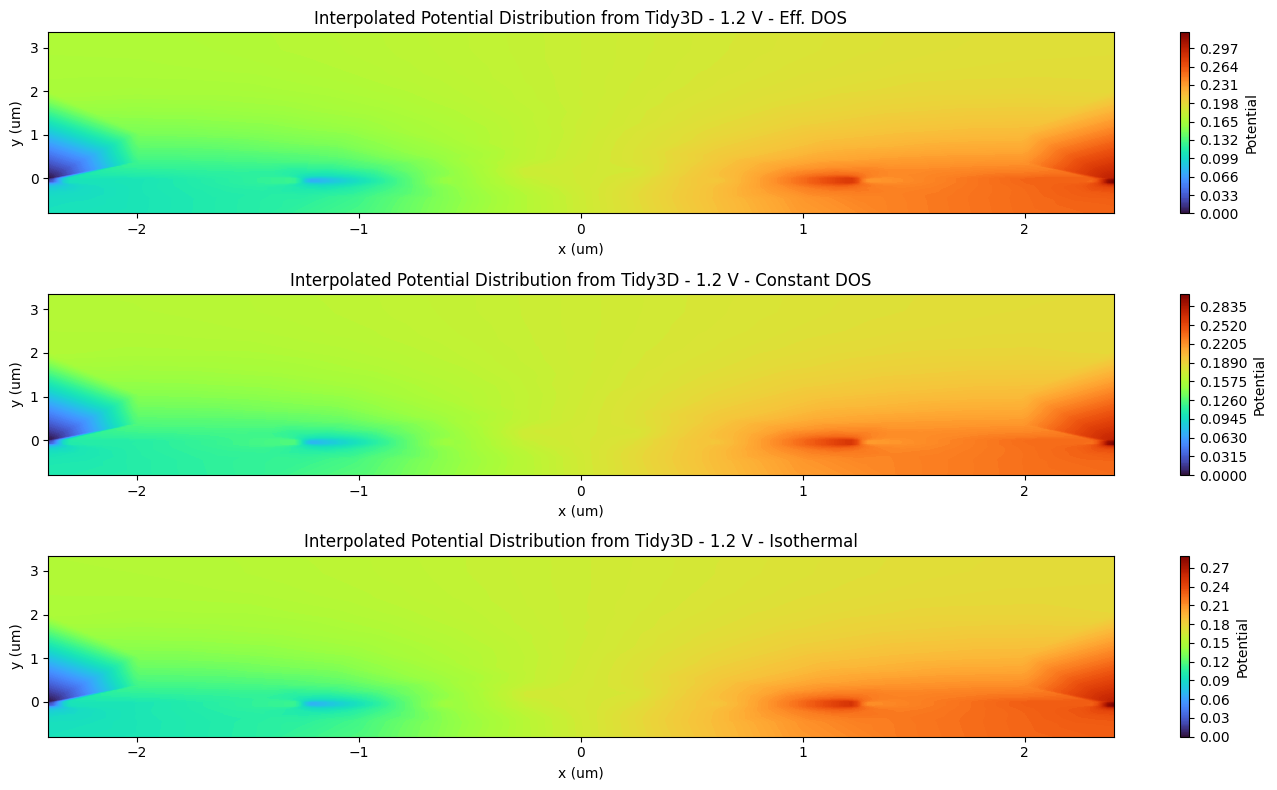

In [25]:
showGrid = False

fig, (ax) = plt.subplots(3, 1, figsize=(14, 8))

contour0 = ax[0].contourf(XI1, YI1, VI_effdos_12V - VI_effdos_12V.min(), levels=250, cmap='turbo')  # Set the maximum value for the color scale
ax[0].set_xlabel('x (um)')
ax[0].set_ylabel('y (um)')
ax[0].set_title('Interpolated Potential Distribution from Tidy3D - 1.2 V - Eff. DOS')
fig.colorbar(contour0, label='Potential', ax=ax[0])


contour1 = ax[1].contourf(XI1, YI1, VI_cst_12V- VI_cst_12V.min(), levels=250, cmap='turbo')  # Set the maximum value for the color scale
ax[1].set_xlabel('x (um)')
ax[1].set_ylabel('y (um)')
ax[1].set_title('Interpolated Potential Distribution from Tidy3D - 1.2 V - Constant DOS')
fig.colorbar(contour1, label='Potential', ax=ax[1])


contour2 = ax[2].contourf(XI1, YI1, VI_iso_12V - VI_iso_12V.min(), levels=250, cmap='turbo')  # Set the maximum value for the color scale
ax[2].set_xlabel('x (um)')
ax[2].set_ylabel('y (um)')
ax[2].set_title('Interpolated Potential Distribution from Tidy3D - 1.2 V - Isothermal')
fig.colorbar(contour2, label='Potential', ax=ax[2])

plt.tight_layout()

### Temperature distribution

In [26]:
# Interpolating Tidy3d results - Eff. DOS
x_vector1 = results["temp_mnt"].temperature.points[:, 0].values
y_vector1 = results["temp_mnt"].temperature.points[:, 1].values
t_vector1 = results["temp_mnt"].temperature.sel(voltage=1.2).values.values[:,0]
XI1, YI1, TI1 = getInterpolatedData(x_vector1, y_vector1, t_vector1)

# Interpolating Tidy3d results - cst
t_vector_cst = results_cst["temp_mnt"].temperature.sel(voltage=1.2).values.values[:,0]
XI1, YI1, TI_cst = getInterpolatedData(x_vector1, y_vector1, t_vector_cst)

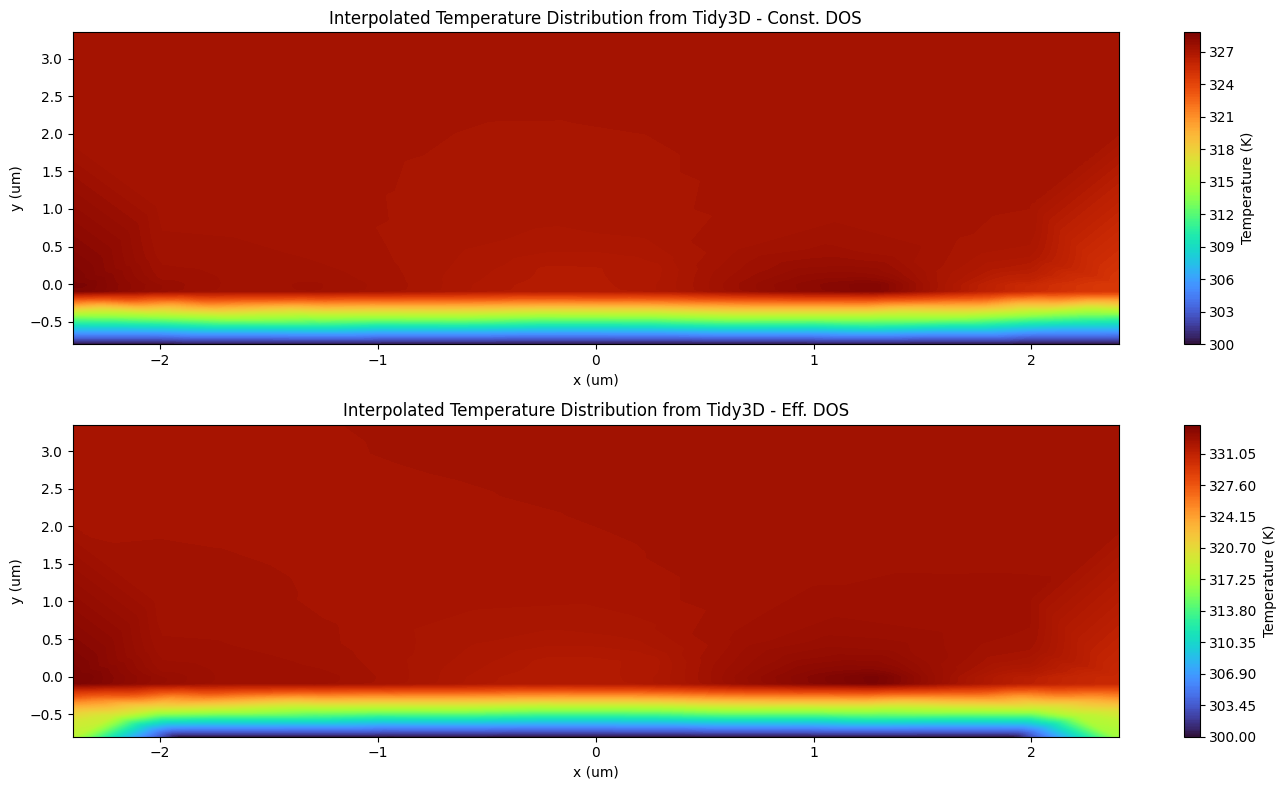

In [27]:
showGrid = False

fig, (ax) = plt.subplots(2, 1, figsize=(14, 8))

contour0 = ax[0].contourf(XI1, YI1, TI_cst, levels=250, cmap='turbo')
ax[0].set_xlabel('x (um)')
ax[0].set_ylabel('y (um)')
ax[0].set_title('Interpolated Temperature Distribution from Tidy3D - Const. DOS')
fig.colorbar(contour0, label='Temperature (K)', ax=ax[0])


contour1 = ax[1].contourf(XI1, YI1, TI1, levels=250, cmap='turbo')
ax[1].set_xlabel('x (um)')
ax[1].set_ylabel('y (um)')
ax[1].set_title('Interpolated Temperature Distribution from Tidy3D - Eff. DOS')
fig.colorbar(contour1, label='Temperature (K)', ax=ax[1])


plt.tight_layout()

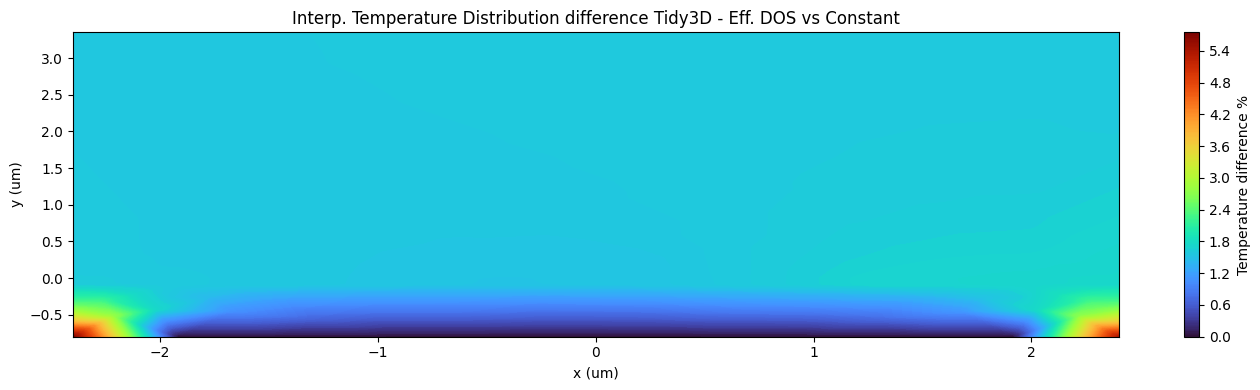

In [28]:
showGrid = False

fig, (ax) = plt.subplots(1, 1, figsize=(14, 4))

contour1 = ax.contourf(XI1, YI1, 100*np.abs((TI_cst-TI1)/TI1), levels=250, cmap='turbo')
ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.set_title('Interp. Temperature Distribution difference Tidy3D - Eff. DOS vs Constant')
fig.colorbar(contour1, label='Temperature difference %', ax=ax)

plt.tight_layout()

### IV-Curve

In [29]:
norm_length = 500
voltage = results.device_characteristics.steady_dc_current_voltage['v'].as_numpy()
current = results.device_characteristics.steady_dc_current_voltage.values*norm_length
current_cst = results_cst.device_characteristics.steady_dc_current_voltage.values*norm_length
current_iso = results_iso.device_characteristics.steady_dc_current_voltage.values*norm_length

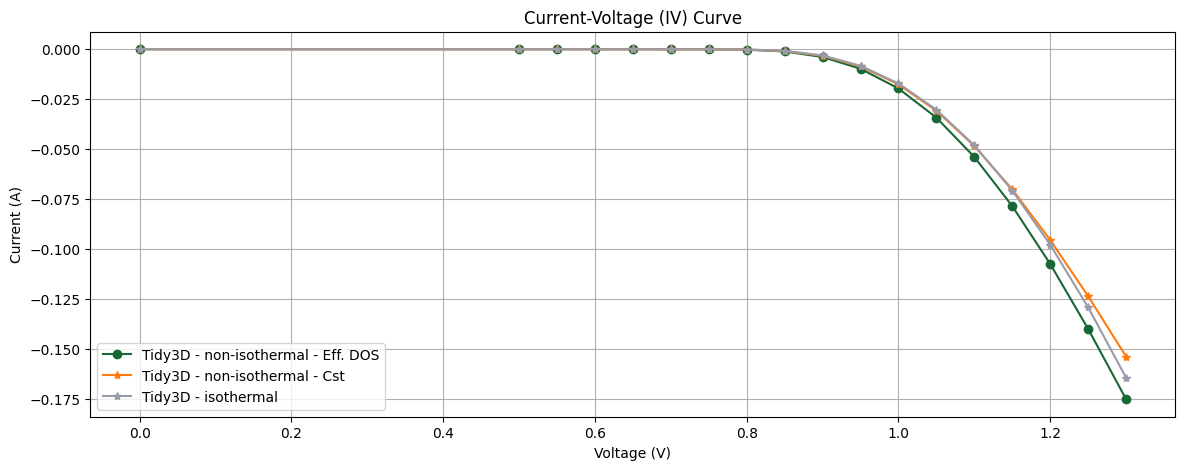

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(voltage, current, marker='o', linestyle='-')
ax.plot(voltage, current_cst, marker='*', linestyle='-')
ax.plot(voltage, current_iso, marker='*', linestyle='-')
# --- ADJUSTED LABELS ---
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Current (A)")
ax.set_title("Current-Voltage (IV) Curve")
ax.legend(['Tidy3D - non-isothermal - Eff. DOS',
           'Tidy3D - non-isothermal - Cst',
           'Tidy3D - isothermal'])
ax.grid(True, which="both", ls="-") 
plt.show()